In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.graphics.factorplots import interaction_plot
import scipy.stats as stats
from bioinfokit.analys import stat

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Gene of interest
goi = "GOI"
# Reference genes (list)
ref_list = ["UBQ", "ACT"]
# Control sample
ctlName = "Control"

In [3]:
#df = pd.read_csv("exp.csv", header=0)
df = pd.read_csv("exp_simulated.csv", header=0)

In [4]:
# Mean Cq of each sample
mdf = df.groupby(["Target", "Sample", "Batch"], as_index=False).mean().rename({"Cq": "MCq"}, axis=1)

# Mean Cq of each biological group
mmdf = mdf.groupby(["Target", "Sample"], as_index = False).MCq.mean()

ctlMCq = list(mmdf[mmdf.Sample==ctlName].MCq)

# Relative Quantity (in biological group)
mmdf["RQ"] = [2 ** (ctlMCq[int(i // (len(mmdf) / len(ctlMCq)))] - mmdf.MCq[i]) for i in range(len(mmdf))]

# Normalized Expression of Relative Quantity (in biological group)
dfgoi = mmdf[mmdf.Target==goi].copy().reset_index(drop=True)
# Calculate geometric mean of reference genes RQ
rq_ref_geomean_list = []
for sample_idx in range(len(mmdf[mmdf.Target==ref_list[0]])):
    rq_values = [mmdf[mmdf.Target==ref].reset_index(drop=True).RQ[sample_idx] for ref in ref_list]
    geomean = math.prod(rq_values) ** (1 / len(rq_values))
    rq_ref_geomean_list.append(geomean)
dfgoi["NE"] = list(mmdf[mmdf.Target==goi].RQ.values / np.array(rq_ref_geomean_list))

# Relative Quantity of each sample for each reference gene and GOI
RQ_refs = {}
for ref_gene in ref_list:
    RQ_refs[ref_gene] = [2 ** (ctlMCq[ref_list.index(ref_gene)]-mdf[mdf.Target==ref_gene].reset_index(drop=True).MCq[i]) for i in range(len(mdf[mdf.Target==ref_gene]))]

RQ_goi = [2 ** (ctlMCq[len(ref_list)]-mdf[mdf.Target==goi].reset_index(drop=True).MCq[i]) for i in range(len(mdf[mdf.Target==goi]))]

# Normalized Expression of each sample (using geometric mean of reference genes)
RNEgoi = []
for i in range(len(RQ_goi)):
    rq_ref_values = [RQ_refs[ref_gene][i] for ref_gene in ref_list]
    rq_ref_geomean = math.prod(rq_ref_values) ** (1 / len(rq_ref_values))
    RNEgoi.append(RQ_goi[i] / rq_ref_geomean)

## Gene Expression Data Table - Verbose

In [5]:
mdfgoi = mdf[mdf.Target==goi].copy().reset_index(drop=True)
mdfgoi["RNE"] = RNEgoi
mdfgoi["RNE_lg"] = [math.log(e, 2) for e in RNEgoi]
mdfgoi

,Target,Sample,Batch,MCq,RNE,RNE_lg
0,GOI,Control,Batch1,18.701228,4.522151e-07,-21.076488
1,GOI,Control,Batch2,21.884201,9.224390e-07,-20.048043
2,GOI,Control,Batch3,26.281815,8.641221e-07,-20.142261
3,GOI,Treatment_A,Batch1,18.460948,6.669632e-07,-20.515889
4,GOI,Treatment_A,Batch2,22.471339,7.766096e-07,-20.296307
5,GOI,Treatment_A,Batch3,26.371988,7.103267e-07,-20.425014
6,GOI,Treatment_B,Batch1,18.375435,8.219841e-07,-20.214386
7,GOI,Treatment_B,Batch2,21.620945,1.596657e-06,-19.256514
8,GOI,Treatment_B,Batch3,25.576904,1.304243e-06,-19.548356
9,GOI,Treatment_C,Batch1,17.672683,1.055403e-06,-19.853774


## Gene Expression Data Table

In [6]:
dfgoi["SEM_lg"] = mdfgoi.groupby(["Target", "Sample"], as_index=False).RNE_lg.sem().RNE_lg
dfgoi

,Target,Sample,MCq,RQ,NE,SEM_lg
0,GOI,Control,22.289081,1.000000,1.000000,0.328241
1,GOI,Treatment_A,22.434759,0.903955,1.006858,0.063701
2,GOI,Treatment_B,21.857761,1.348467,1.680836,0.283459
3,GOI,Treatment_C,21.803786,1.399872,1.652253,0.160270


## Bar Chart w/ SEM

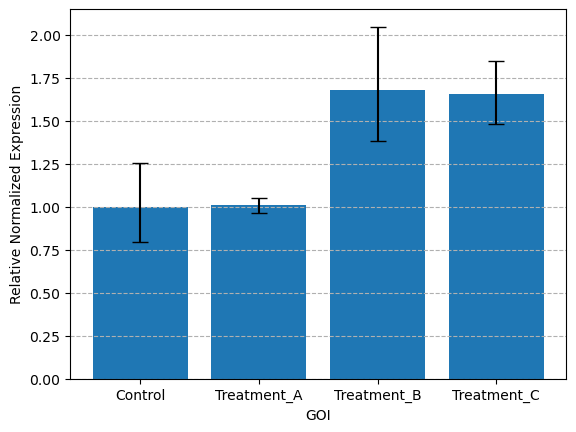

In [7]:
ue = [2 ** (math.log(dfgoi.NE[i], 2) + dfgoi.SEM_lg[i]) - dfgoi.NE[i] for i in range(len(dfgoi))]
le = [dfgoi.NE[i] - 2 ** (math.log(dfgoi.NE[i], 2) - dfgoi.SEM_lg[i]) for i in range(len(dfgoi))]

x = np.arange(len(dfgoi))
plt.bar(x, dfgoi.NE, yerr=[le, ue], capsize=6)
plt.grid(axis="y", linestyle="--")
plt.xticks(x, dfgoi.Sample)
plt.xlabel(goi)
plt.ylabel("Relative Normalized Expression")
plt.show()

## Boxplot w/ Scatter

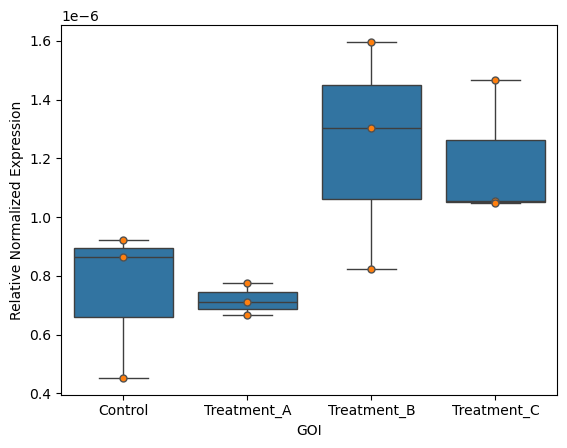

In [8]:
ax = sns.boxplot(data=mdfgoi, x="Sample", y="RNE", boxprops={"alpha": 1})
sns.stripplot(data=mdfgoi, x="Sample", y="RNE",linewidth=1, jitter=False, ax=ax)
plt.xlabel(goi)
plt.ylabel("Relative Normalized Expression")
plt.show()

In [9]:
# Batch (block) as int may cause wrong df
mdfgoi.Batch = mdfgoi.Batch.apply(str)

In [10]:
mdfgoi.pivot(index="Sample", columns="Batch", values="RNE_lg")

Batch,Batch1,Batch2,Batch3
Sample,,,
Control,-21.076488,-20.048043,-20.142261
Treatment_A,-20.515889,-20.296307,-20.425014
Treatment_B,-20.214386,-19.256514,-19.548356
Treatment_C,-19.853774,-19.377328,-19.862385


## ONE-WAY ANOVA

In [11]:
res = stat()
m_formula = "RNE_lg ~ C(Sample)"
res.anova_stat(df=mdfgoi, res_var="RNE_lg", anova_model=m_formula)
res.anova_summary

,df,sum_sq,mean_sq,F,PR(>F)
C(Sample),3.0,1.607994,0.535998,3.280753,0.079527
Residual,8.0,1.307012,0.163377,NaN,NaN


### Post-hoc analyses

In [12]:
# Tukey HSD
res = stat()
# for main effect Sample
res.tukey_hsd(df=mdfgoi, res_var="RNE_lg", xfac_var="Sample", anova_model=m_formula)
res.tukey_summary

/lib/python3.11/site-packages/bioinfokit/analys.py:431: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  mult_group[ele] = df[df[xfac_var] == ele].mean().loc[res_var]
/lib/python3.11/site-packages/bioinfokit/analys.py:431: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  mult_group[ele] = df[df[xfac_var] == ele].mean().loc[res_var]
/lib/python3.11/site-packages/bioinfokit/analys.py:431: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying

,group1,group2,Diff,Lower,Upper,q-value,p-value
0,Control,Treatment_A,0.009861,-1.047109,1.066831,0.042254,0.900000
1,Control,Treatment_B,0.749179,-0.307791,1.806149,3.210342,0.184486
2,Control,Treatment_C,0.724435,-0.332535,1.781405,3.104311,0.204201
3,Treatment_A,Treatment_B,0.739318,-0.317652,1.796288,3.168088,0.192128
4,Treatment_A,Treatment_C,0.714574,-0.342396,1.771544,3.062057,0.212561
5,Treatment_B,Treatment_C,0.024744,-1.032226,1.081714,0.106031,0.900000


## SET BATCH AS BLOCK EFFECT (RCBD)
### Two-Way ANOVA wo/ interaction


In [13]:
res = stat()
m_formula = "RNE_lg ~ C(Sample) + C(Batch)"
res.anova_stat(df=mdfgoi, res_var="RNE_lg", anova_model=m_formula)
res.anova_summary

,df,sum_sq,mean_sq,F,PR(>F)
C(Sample),3.0,1.607994,0.535998,8.283921,0.014867
C(Batch),2.0,0.918792,0.459396,7.100024,0.026206
Residual,6.0,0.388221,0.064703,NaN,NaN


### Post-hoc analyses

In [14]:
# Tukey HSD
res = stat()
# for main effect Sample
res.tukey_hsd(df=mdfgoi, res_var="RNE_lg", xfac_var="Sample", anova_model=m_formula)
res.tukey_summary

/lib/python3.11/site-packages/bioinfokit/analys.py:431: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  mult_group[ele] = df[df[xfac_var] == ele].mean().loc[res_var]
/lib/python3.11/site-packages/bioinfokit/analys.py:431: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  mult_group[ele] = df[df[xfac_var] == ele].mean().loc[res_var]
/lib/python3.11/site-packages/bioinfokit/analys.py:431: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying

,group1,group2,Diff,Lower,Upper,q-value,p-value
0,Control,Treatment_A,0.009861,-0.709204,0.728925,0.067143,0.900000
1,Control,Treatment_B,0.749179,0.030114,1.468243,5.101319,0.042334
2,Control,Treatment_C,0.724435,0.005370,1.443499,4.932833,0.048527
3,Treatment_A,Treatment_B,0.739318,0.020254,1.458383,5.034176,0.044692
4,Treatment_A,Treatment_C,0.714574,-0.004490,1.433639,4.865690,0.051264
5,Treatment_B,Treatment_C,0.024744,-0.694321,0.743808,0.168486,0.900000


In [15]:
# for block effect Batch
res.tukey_hsd(df=mdfgoi, res_var="RNE_lg", xfac_var="Batch", anova_model=m_formula)
res.tukey_summary

/lib/python3.11/site-packages/bioinfokit/analys.py:431: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  mult_group[ele] = df[df[xfac_var] == ele].mean().loc[res_var]
/lib/python3.11/site-packages/bioinfokit/analys.py:431: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  mult_group[ele] = df[df[xfac_var] == ele].mean().loc[res_var]
/lib/python3.11/site-packages/bioinfokit/analys.py:431: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying

,group1,group2,Diff,Lower,Upper,q-value,p-value
0,Batch1,Batch2,0.670586,0.119352,1.221820,5.272554,0.022658
1,Batch1,Batch3,0.420630,-0.130604,0.971864,3.307249,0.125002
2,Batch2,Batch3,0.249956,-0.301278,0.801190,1.965305,0.404034


## Interaction plot

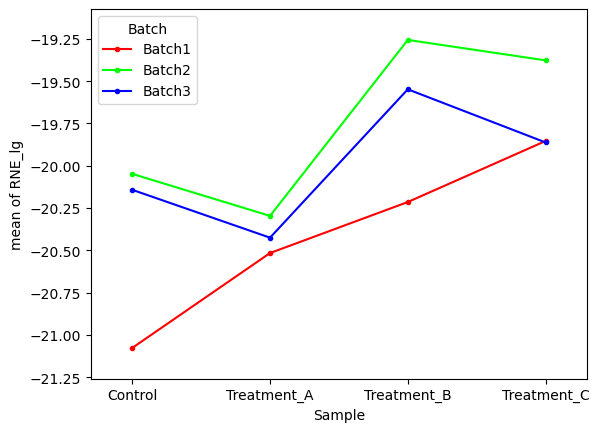

In [16]:
# Interaction plot
fig = interaction_plot(x=mdfgoi["Sample"], trace=mdfgoi["Batch"], response=mdfgoi["RNE_lg"])
plt.show()

### Test ANOVA assumptions

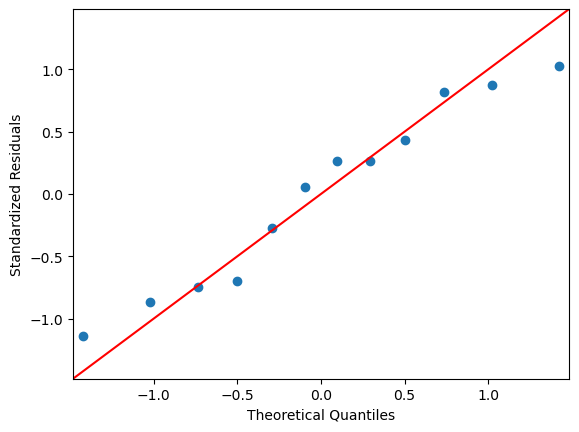

In [17]:
# res.anova_std_residuals are standardized residuals obtained from ANOVA (check above)
sm.qqplot(res.anova_std_residuals, line="45")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Standardized Residuals")
plt.show()

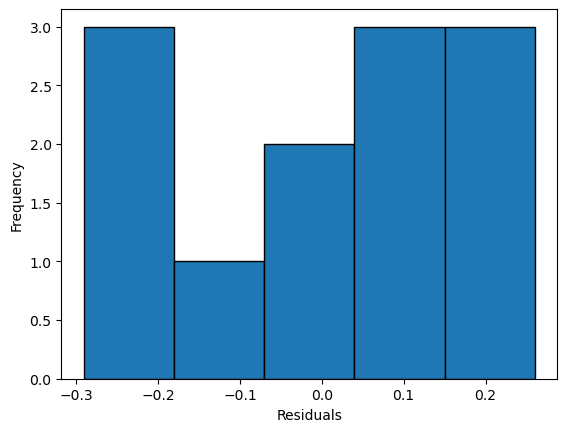

In [18]:
# histogram
plt.hist(res.anova_model_out.resid, bins="auto", histtype="bar", ec="k") 
plt.xlabel("Residuals")
plt.ylabel('Frequency')
plt.show()

In [19]:
# Shapiro-Wilk test - normal distribution of residuals
## H0: data is drawn from normal distribution
model = ols(m_formula, data=mdfgoi).fit()
w, pvalue = stats.shapiro(model.resid)
print(w, pvalue)

0.9359188079833984 0.44707581400871277


In [20]:
# Bartlett’s test - homogeneity of variances when the data is drawn from normal distribution
## H0: samples from populations have equal variances
res = stat()
res.bartlett(df=mdfgoi, res_var="RNE_lg", xfac_var="Sample")
res.bartlett_summary

,Parameter,Value
0,Test statistics (T),3.7689
1,Degrees of freedom (Df),3.0000
2,p value,0.2875


In [21]:
# Levene’s test - homogeneity of variances when the data is not drawn from normal distribution
## H0: samples from populations have equal variances
res = stat()
res.levene(df=mdfgoi, res_var="RNE_lg", xfac_var="Sample")
res.levene_summary

,Parameter,Value
0,Test statistics (W),0.4383
1,Degrees of freedom (Df),3.0000
2,p value,0.7318


### Efficiency of blocking

In [22]:
# If there is no treatment effect, then F = MSB/MSE
# If F = 1, blocking is irrelevant to the result
# If F < 1, blocking is misplaced and therefore jeopardizes the result
# If F > 1, blocking is beneficial to the result
m_formula = "RNE_lg ~ C(Batch)"
res.anova_stat(df=mdfgoi, res_var="RNE_lg", anova_model=m_formula)
res.anova_summary

,df,sum_sq,mean_sq,F,PR(>F)
C(Batch),2.0,0.918792,0.459396,2.071201,0.181993
Residual,9.0,1.996215,0.221802,NaN,NaN
